Data saved to plasma_data_analytical_z1.csv


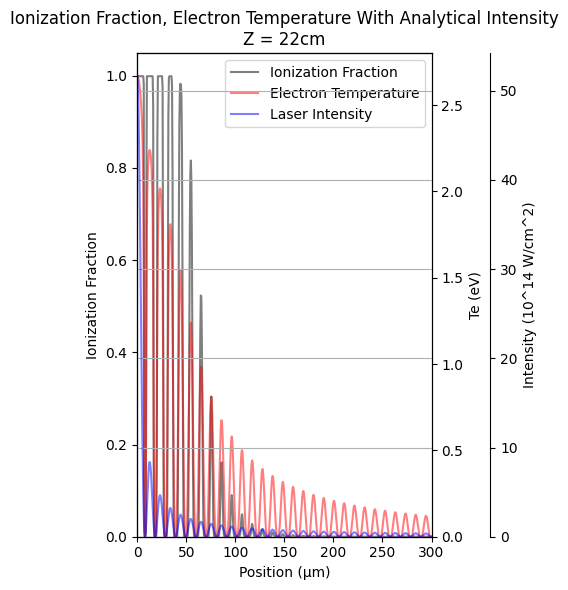


Integration results:
Integration range: 0 to 3.96e-02 meters
Integral value (J/m): 1.68e-03
Integration error: 6.04e-08
Relative error: 3.59e-05
Final energy (erg/cm): 1.68e+02
Data saved to plasma_data_z1.csv


/var/folders/kq/4wb4bwzd1d381_jymps9w97c0000gn/T/ipykernel_96988/696253918.py:164: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_value, error = quad(integrand, r_points[i], r_points[i+1], limit=200)


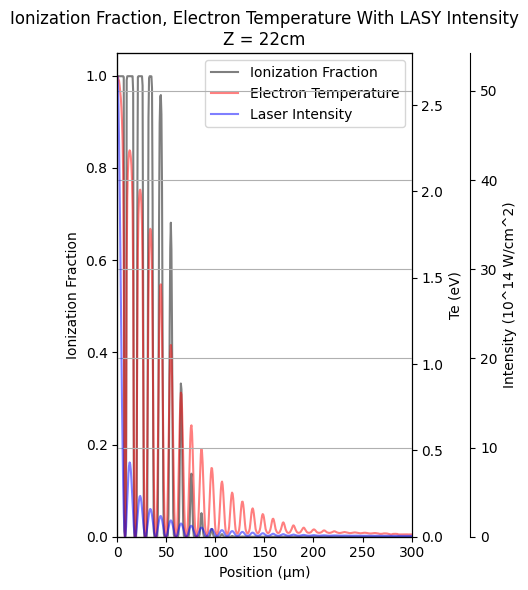

Processing z = 22.0 cm (1/20)
Processing z = 23.6 cm (2/20)
Processing z = 25.2 cm (3/20)
Processing z = 26.7 cm (4/20)
Processing z = 28.3 cm (5/20)
Processing z = 29.9 cm (6/20)
Processing z = 31.5 cm (7/20)
Processing z = 33.1 cm (8/20)
Processing z = 34.6 cm (9/20)
Processing z = 36.2 cm (10/20)
Processing z = 37.8 cm (11/20)
Processing z = 39.4 cm (12/20)
Processing z = 40.9 cm (13/20)
Processing z = 42.5 cm (14/20)
Processing z = 44.1 cm (15/20)
Processing z = 45.7 cm (16/20)
Processing z = 47.3 cm (17/20)
Processing z = 48.8 cm (18/20)
Processing z = 50.4 cm (19/20)
Processing z = 52.0 cm (20/20)


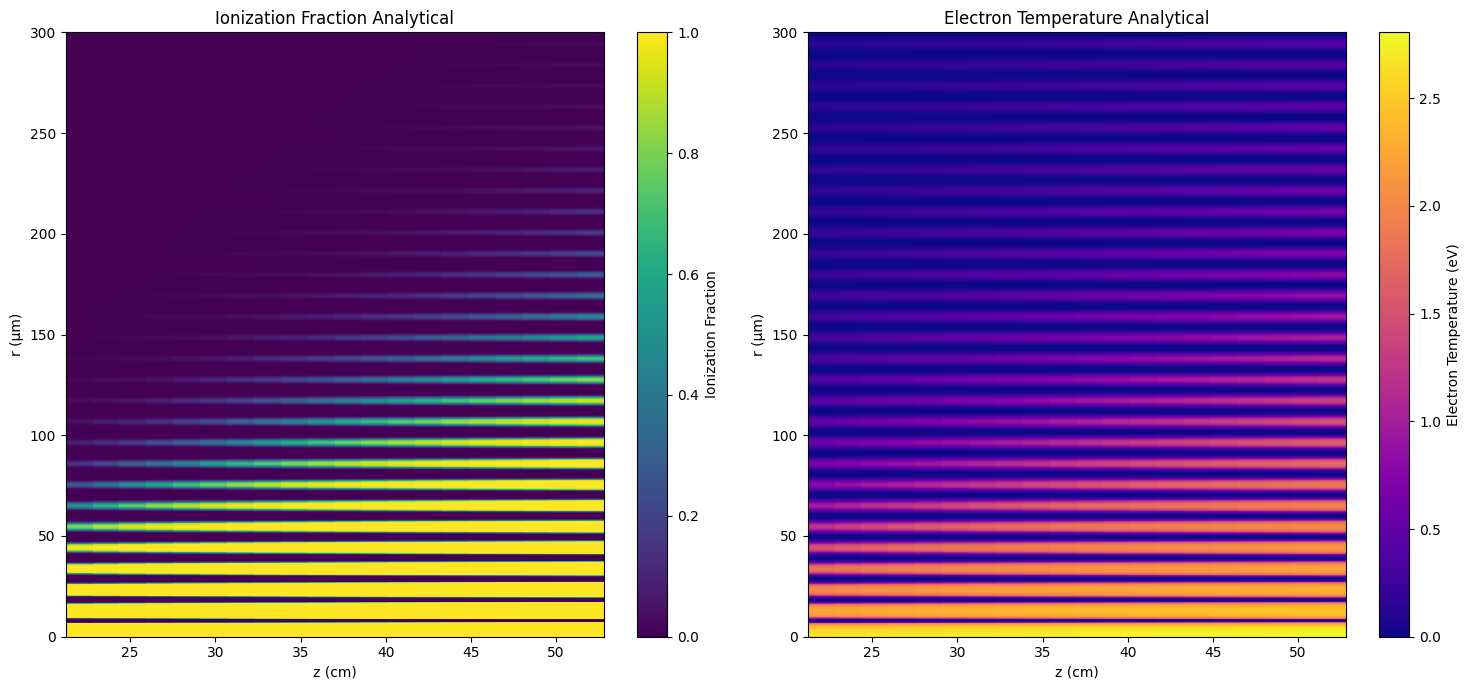

Processing z position 1/20 at z = 22.0 cm
Processing z position 2/20 at z = 23.6 cm
Processing z position 3/20 at z = 25.2 cm
Processing z position 4/20 at z = 26.7 cm
Processing z position 5/20 at z = 28.3 cm
Processing z position 6/20 at z = 29.9 cm
Processing z position 7/20 at z = 31.5 cm
Processing z position 8/20 at z = 33.1 cm
Processing z position 9/20 at z = 34.6 cm
Processing z position 10/20 at z = 36.2 cm
Processing z position 11/20 at z = 37.8 cm
Processing z position 12/20 at z = 39.4 cm
Processing z position 13/20 at z = 40.9 cm
Processing z position 14/20 at z = 42.5 cm
Processing z position 15/20 at z = 44.1 cm
Processing z position 16/20 at z = 45.7 cm
Processing z position 17/20 at z = 47.3 cm
Processing z position 18/20 at z = 48.8 cm
Processing z position 19/20 at z = 50.4 cm
Processing z position 20/20 at z = 52.0 cm


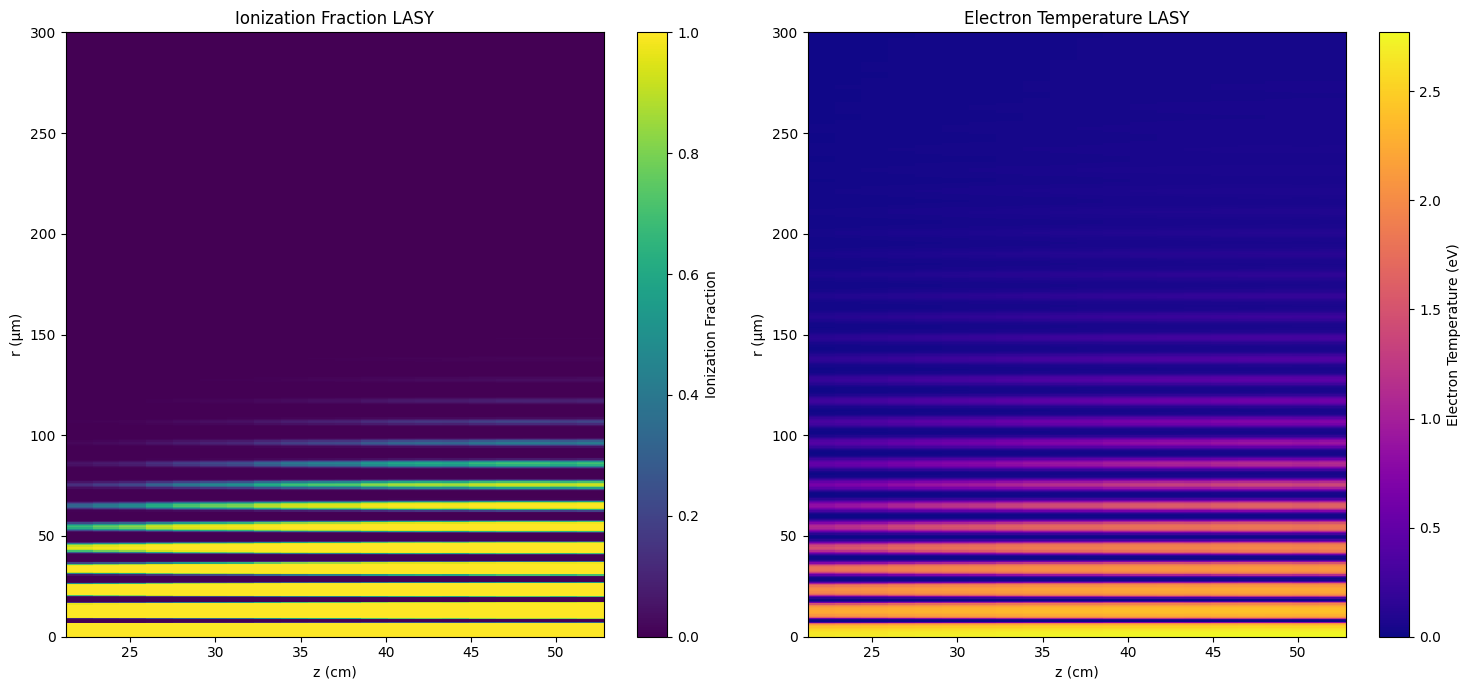

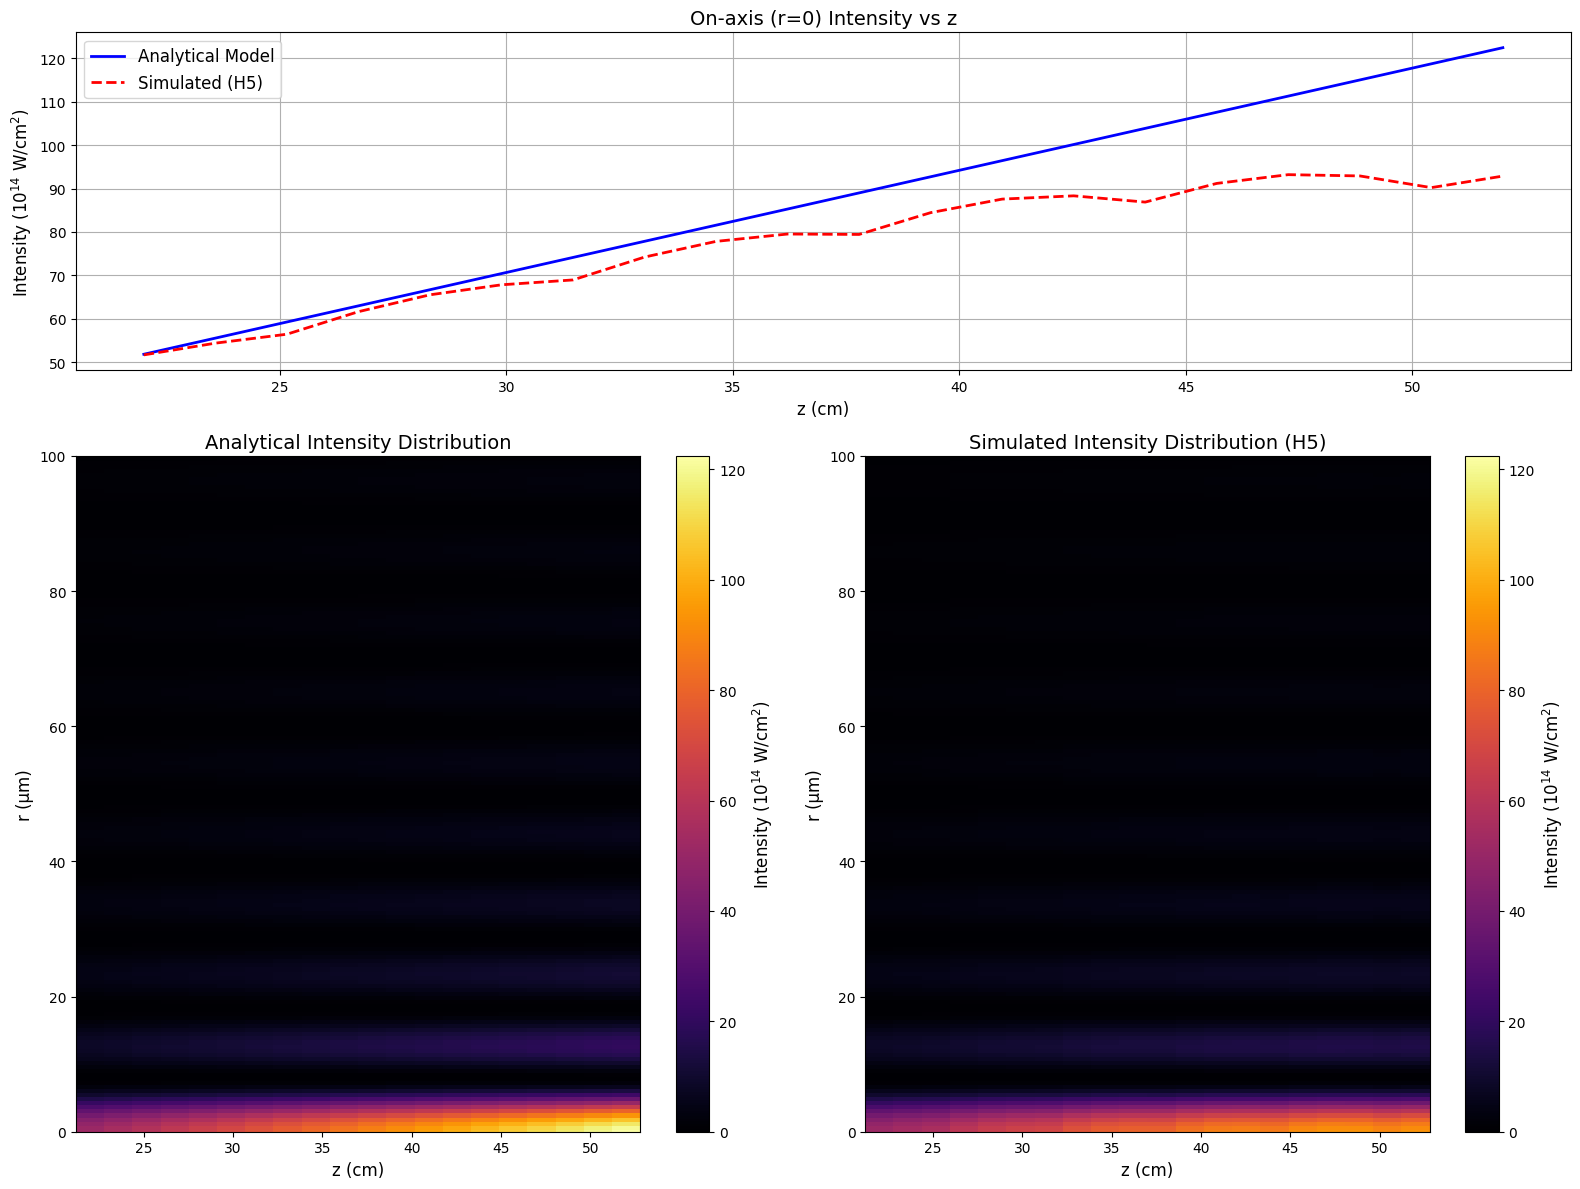


Summary Statistics:
Maximum on-axis intensity difference: 29.5896 × 10^14 W/cm^2
Mean on-axis intensity difference: 9.8898 × 10^14 W/cm^2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from scipy.constants import m_e, c, e, hbar, physical_constants, epsilon_0, pi
from scipy.special import gamma, jv
from scipy.integrate import quad
from scipy.interpolate import interp1d
import numba

# ======== CONSTANTS AND PARAMETERS ========
# Physical constants
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e
k = 1.380649e-23  # Boltzmann constant

# Ionization parameters for Hydrogen
UH = 13.6*e
Uion = 13.6*e  # ionization energy in Joules, for Hydrogen
Z = 1
n_eff = Z * np.sqrt(UH/Uion)
l_eff = n_eff - 1
C2 = 2**(2*n_eff) / (n_eff * gamma(n_eff+l_eff+1) * gamma(n_eff-l_eff))

# ADK prefactors - for l=0, m=0
adk_power = -(2*n_eff - 1)
adk_prefactor = wa * C2 * (Uion/(2*UH)) * (2*(Uion/UH)**(3./2)*Ea)**(2*n_eff - 1)
adk_exp_prefactor = -2./3 * (Uion/UH)**(3./2) * Ea

# Default laser parameters
DEFAULT_WAVELENGTH = 0.8e-6  # wavelength in meters
DEFAULT_PULSE_DURATION = 40e-15  # pulse duration in seconds
DEFAULT_POLARIZATION = [1.0, 0.0]  # linear polarization [delta_x, delta_y]
DEFAULT_ANGLE_DEG = 2.2  # angle in degrees for analytical model
DEFAULT_RADIUS = 0.033  # characteristic radius in meters
DEFAULT_EPSILON = 0.555  # intensity scaling factor

# ======== CORE FUNCTIONS ========
@numba.njit
def get_ib_heating_rate(a, n0, kin_energy, ioniz_frac, lambd):
    """Calculate inverse bremsstrahlung heating rate"""
    # Compute thermal velocity
    kin_energy_per_electron = kin_energy/ioniz_frac
    vth_over_c = np.sqrt(kin_energy_per_electron/(3/2*m_e*c**2))
    
    # Compute Coulomb log
    vbar_over_c = np.sqrt(vth_over_c**2 + a**2/6)
    bmin = 0.5*hbar/(m_e*c*vbar_over_c)
    bmax = vbar_over_c * lambd/(2*np.pi)
    bperp = r_e / vbar_over_c**2
    C_log = 0.5*np.log((1 + (bmax/bperp)**2)/(1 + (bmin/bperp)**2))

    # Compute heating rate
    n_i = n0*ioniz_frac
    if (vth_over_c > a):
        nu_ei = 4*(2*np.pi)**.5/3 * (n_i * r_e**2 * c) * C_log/vth_over_c**3
    else:
        nu_ei = 16 * (n_i * r_e**2 * c) * C_log / a**3 * np.log(2**.5 * a/vth_over_c)

    heating_per_electron = 0.5 * m_e*c**2 * a**2 * nu_ei
    return heating_per_electron

@numba.njit
def get_fraction_and_temperature(a0, tau, lambd, ell, npts_per_wavelength=80, 
                             compute_inverse_bremsstrahlung=False, n0=1.e24, npts_per_tau_ib=80):
    """
    Calculate ionization fraction and temperature for given laser parameters
    
    Parameters:
    a0: Peak laser amplitude
    tau: laser duration
    lambd: laser wavelength
    ell: polarization vector
    n0: electron density if the plasma was fully ionized
    """
    # Precompute a few things
    omega = 2*np.pi*c/lambd
    E0 = m_e*omega*c/e
    inv_tau2 = 1./tau**2
    
    # Check the ellipticity
    assert len(ell) == 2
    assert abs(ell[0]**2 + ell[1]**2 - 1) < 1.e-10  # Check that the ellipticity is normalized

    t = -3*tau  # Start at 3 sigma
    ioniz_frac = 0
    kin_energy = 0

    # Loop for ADK: small timestep
    dt = lambd/c/npts_per_wavelength
    while ((ioniz_frac < 0.999) and (t < 3*tau)):
        # Get the electric field and vector potential
        a_env = a0 * np.exp(-2 * np.log(2) * inv_tau2*t**2)
        a = a_env * np.sqrt(ell[0]**2*np.cos(omega*t)**2 + ell[1]**2*np.sin(omega*t)**2)
        E = E0 * a_env * np.sqrt(ell[0]**2*np.sin(omega*t)**2 + ell[1]**2*np.cos(omega*t)**2)                           

        # Get the ionization rate
        w = 0
        if E > 0:
            w = adk_prefactor * E**adk_power * np.exp(adk_exp_prefactor/E)
        dp = 1 - np.exp(-w*dt)

        # increment the ionization fraction
        kin_energy += (1 - ioniz_frac)*dp * m_e*c**2 * (np.sqrt(1 + a**2) - 1)
        ioniz_frac += (1 - ioniz_frac)*dp

        if compute_inverse_bremsstrahlung and (ioniz_frac > 0):
            kin_energy += dt * ioniz_frac * get_ib_heating_rate(a_env, n0, kin_energy, ioniz_frac, lambd)

        t += dt

    # Once the plasma is fully ionized we can take much larger timesteps to compute IB
    if compute_inverse_bremsstrahlung:
        dt = tau/npts_per_tau_ib        
        while (t < 3*tau):
            a_env = a0 * np.exp(-inv_tau2*t**2)
            kin_energy += dt * ioniz_frac * get_ib_heating_rate(a_env, n0, kin_energy, ioniz_frac, lambd)
            t += dt

    T = 0.
    if ioniz_frac > 0:
        T = kin_energy/(3/2*ioniz_frac*e)

    return ioniz_frac, T, t

def calculate_energy_per_length(r_values, Ionfrac, Te, n0=1e24):
    """
    Calculate energy per unit length using the central part of the profile
    where the actual ionization occurs
    """
    center_idx = len(r_values) // 2
    
    # Use only the part from center (r=0) onwards
    r_values_centered = r_values[center_idx:] - r_values[center_idx]  # Shift to start at r=0
    Ionfrac_centered = Ionfrac[center_idx:]
    Te_centered = Te[center_idx:]
    
    # Create interpolation functions
    alpha_interp = interp1d(r_values_centered, Ionfrac_centered, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    Te_interp = interp1d(r_values_centered, Te_centered, kind='linear',
                        bounds_error=False, fill_value=0.0)
    
    def integrand(r):
        alpha = alpha_interp(r)
        Te_ev = Te_interp(r)
        Te_K = Te_ev * 11604  # Convert eV to K
        # Calculate energy density * radius (for cylindrical integration)
        result = n0 * alpha * 1.5 * k * Te_K * 2 * np.pi * r
        return result
    
    # Integrate with specified maximum radius
    r_max = 0.0396
    n_intervals = 20
    r_points = np.linspace(0, r_max, n_intervals + 1)
    
    total_integral = 0.0
    total_error = 0.0
    
    # Integrate each subinterval
    for i in range(n_intervals):
        integral_value, error = quad(integrand, r_points[i], r_points[i+1], limit=200)
        total_integral += integral_value
        total_error += error
    
    print(f"\nIntegration results:")
    print(f"Integration range: 0 to {r_max:.2e} meters")
    print(f"Integral value (J/m): {total_integral:.2e}")
    print(f"Integration error: {total_error:.2e}")
    print(f"Relative error: {(total_error/total_integral if total_integral != 0 else 0):.2e}")
    
    # Convert from J/m to erg/cm
    energy_per_length_erg_cm = total_integral * 1e7 / 100
    print(f"Final energy (erg/cm): {energy_per_length_erg_cm:.2e}")
    
    return energy_per_length_erg_cm

def get_analytical_intensity(rho, z, bessel_order=0, wavelength=DEFAULT_WAVELENGTH, 
                           alpha_deg=DEFAULT_ANGLE_DEG, R=DEFAULT_RADIUS, 
                           tau=DEFAULT_PULSE_DURATION, epsilon=DEFAULT_EPSILON):
    """
    Calculate analytical intensity profile
    
    Parameters:
    rho : array-like, radial coordinate in meters
    z : float, longitudinal position in meters
    bessel_order : int, order of the Bessel function
    wavelength : float, laser wavelength in meters
    alpha_deg : float, angle in degrees
    R : float, characteristic radius in meters
    tau : float, pulse duration in seconds
    epsilon : float, intensity scaling factor
    """
    k = 2 * pi / wavelength
    alpha = np.deg2rad(alpha_deg)
    
    # Calculate intensity using the provided formula
    intensity = (epsilon * 2 * np.sqrt(2) * k * z * np.tan(alpha) * np.sin(alpha) / 
                (np.sqrt(pi) * R**2 * tau) * 
                jv(bessel_order, k * rho * np.sin(alpha))**2 * 
                np.where(rho <= R, 1.0, 0.0))  # This implements H(R - r)
        
    return intensity

# ======== DATA PROCESSING FUNCTIONS ========
def process_intensity(source, z_position=0.22, num_points=3000, rho_max=800e-6, 
                    output_file=None, compute_ib=False, n0=1e24,
                    wavelength=DEFAULT_WAVELENGTH, tau=DEFAULT_PULSE_DURATION, 
                    ell=DEFAULT_POLARIZATION):
    """
    Process intensity profile from either analytical formula or H5 file
    
    Parameters:
    source: str or 'analytical', path to h5 file or keyword for analytical calculation
    z_position: float, position along z-axis in meters (for analytical calculation)
    """
    # Create symmetric radial coordinate array
    if source == 'analytical':
        rho_full = np.linspace(-rho_max, rho_max, num_points)
        intensity_profile_full = get_analytical_intensity(np.abs(rho_full), z_position)
    else:
        # H5 file processing
        with h5py.File(source, 'r') as f:
            intensity_profile_full = f['intensity_profiles'][0]/1.67 * 0.38
            rho_full = np.linspace(-3.96e-2, 3.96e-2, len(intensity_profile_full))
    
    center_idx = len(rho_full) // 2
    
    # Calculate a0 from intensity
    a0_full = e * wavelength / (pi * m_e * c) * np.sqrt(intensity_profile_full / (2 * epsilon_0 * c**3))
    
    # Initialize arrays for temperature and ionization fraction
    Te_full = np.zeros_like(a0_full)
    Ionfrac_full = np.zeros_like(a0_full)
    
    # Calculate temperature and ionization fraction
    for i in range(len(a0_full)):
        ioniz_frac, T, _ = get_fraction_and_temperature(
            a0_full[i], tau, wavelength, ell, 
            compute_inverse_bremsstrahlung=compute_ib, n0=n0
        )
        Te_full[i] = T
        Ionfrac_full[i] = ioniz_frac
    
    # Calculate energy per length if using H5 file
    energy_per_length = None
    if source != 'analytical':
        energy_per_length = calculate_energy_per_length(rho_full, Ionfrac_full, Te_full, n0)
    
    # Save data if output file is specified
    if output_file:
        temperature_K = Te_full * 11604  # Convert eV to K
        df = pd.DataFrame({
            'Radius (cm)': rho_full[len(rho_full)//2:] * 100,  # Convert m to cm
            'Ionization Fraction': Ionfrac_full[len(rho_full)//2:],
            'Electron Temperature (K)': temperature_K[len(rho_full)//2:]
        })
        df.to_csv(output_file, index=False)
        print(f"Data saved to {output_file}")
    
    return rho_full, Te_full, Ionfrac_full, a0_full, intensity_profile_full, energy_per_length

def plot_intensity_results(rho_full, Te_full, Ionfrac_full, intensity_profile_full, 
                         z_position=None, source_type=""):
    """Plot results from intensity processing"""
    plt.figure(figsize=(5, 6))
    
    # Create plot with three y-axes
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    
    # Offset the third axis spine
    ax3.spines["right"].set_position(("axes", 1.2))
    
    center_idx = len(rho_full) // 2
    
    # Plot ionization fraction
    line1 = ax1.plot(rho_full*1e6, Ionfrac_full, 
                    alpha=0.5, color='black', label='Ionization Fraction')
    ax1.set_xlabel('Position (μm)')
    ax1.set_ylabel('Ionization Fraction')
    ax1.tick_params(axis='y')
    ax1.set_ylim(bottom=0)
    ax1.set_xlim(0, 300)  # Show first 300 μm

    # Plot temperature
    line2 = ax2.plot(rho_full*1e6, Te_full, 
                    alpha=0.5, color='red', label='Electron Temperature')
    ax2.set_ylabel('Te (eV)')
    ax2.tick_params(axis='y')
    ax2.set_ylim(bottom=0)
    
    # Plot laser intensity (converted to W/cm^2)
    intensity_wcm2 = intensity_profile_full * 1e-4  # Convert W/m^2 to W/cm^2
    line3 = ax3.plot(rho_full*1e6, intensity_wcm2*1e-14, 
                    alpha=0.5, color='blue', label='Laser Intensity')
    ax3.set_ylabel('Intensity (10^14 W/cm^2)')
    ax3.tick_params(axis='y')
    ax3.set_ylim(bottom=0)
    
    # Combine all lines and labels for the legend
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    title = f'Ionization Fraction, Electron Temperature With {source_type} Intensity'
    if z_position is not None:
        title += f'\nZ = {z_position*100:.0f}cm'
    plt.title(title)
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def generate_2d_heatmaps(source, z_positions, 
                        ion_cmap='viridis', temp_cmap='plasma',
                        save_plots=True, show_plots=True,
                        wavelength=DEFAULT_WAVELENGTH, 
                        tau=DEFAULT_PULSE_DURATION,
                        ell=DEFAULT_POLARIZATION):
    """
    Generate 2D heatmaps of ionization fraction and electron temperature
    
    Parameters:
    source: str or 'analytical', path to h5 file or keyword for analytical calculation
    z_positions: array-like, positions along z-axis in meters
    """
    num_z = len(z_positions)
    
    if source == 'analytical':
        # Create symmetric radial coordinate array for analytical calculations
        num_points = 3000
        rho_max = 300e-6
        rho_full = np.linspace(-rho_max, rho_max, num_points)
        center_idx = len(rho_full) // 2
        r_values = rho_full[center_idx:]  # Positive values only
        
        # Initialize 2D arrays
        ioniz_frac_2d = np.zeros((num_z, len(r_values)))
        Te_2d = np.zeros((num_z, len(r_values)))
        
        # Process each z position
        for i, z_pos in enumerate(z_positions):
            print(f"Processing z = {z_pos*100:.1f} cm ({i+1}/{len(z_positions)})")
            
            # Get intensity and process it
            _, Te_full, Ionfrac_full, _, _, _ = process_intensity(
                'analytical', z_position=z_pos, num_points=num_points, rho_max=rho_max,
                wavelength=wavelength, tau=tau, ell=ell
            )
            
            # Store results
            ioniz_frac_2d[i, :] = Ionfrac_full[center_idx:]
            Te_2d[i, :] = Te_full[center_idx:]
            
    else:
        # H5 file processing
        with h5py.File(source, 'r') as f:
            # Get dimensions from the first intensity profile
            intensity_profile = f['intensity_profiles'][0]/1.67 * 0.38
            profile_length = len(intensity_profile)
            
            # Create radial coordinate array
            r_values_full = np.linspace(-3.96e-2, 3.96e-2, profile_length)
            center_idx = profile_length // 2
            r_values = r_values_full[center_idx:]  # Positive values only
            
            # Initialize 2D arrays
            ioniz_frac_2d = np.zeros((num_z, len(r_values)))
            Te_2d = np.zeros((num_z, len(r_values)))
            
            # Process each z position
            for i in range(num_z):
                print(f"Processing z position {i+1}/{num_z} at z = {z_positions[i]*100:.1f} cm")
                
                try:
                    # Read intensity profile for this z position
                    intensity_profile = f['intensity_profiles'][i]/1.67 * 0.38
                    
                    # Calculate a0 from intensity
                    a0 = e * wavelength / (pi * m_e * c) * np.sqrt(
                        intensity_profile / (2 * epsilon_0 * c**3)
                    )
                    
                    # Calculate temperature and ionization fraction
                    Te = np.zeros_like(a0)
                    Ionfrac = np.zeros_like(a0)
                    
                    for j in range(len(a0)):
                        ioniz_frac, T, _ = get_fraction_and_temperature(
                            a0[j], tau, wavelength, ell
                        )
                        Te[j] = T
                        Ionfrac[j] = ioniz_frac
                    
                    # Store results
                    ioniz_frac_2d[i, :] = Ionfrac[center_idx:]
                    Te_2d[i, :] = Te[center_idx:]
                    
                except Exception as err:
                    print(f"Error processing z position {i}: {err}")
                    # Fill with zeros if processing fails
                    ioniz_frac_2d[i, :] = 0
                    Te_2d[i, :] = 0
    
    # Convert units for plotting
    r_values_microns = r_values * 1e6  # m to μm
    z_positions_cm = np.array(z_positions) * 100  # m to cm
    
    # Find max temperature for consistent colorbar
    max_Te = np.max(Te_2d)
    
    if show_plots:
        # Create the heatmaps
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
        
        # Ionization fraction heatmap
        im1 = ax1.pcolormesh(z_positions_cm, r_values_microns, ioniz_frac_2d.T, 
                            cmap=ion_cmap, shading='auto', vmin=0, vmax=1)
        cbar1 = fig.colorbar(im1, ax=ax1)
        cbar1.set_label('Ionization Fraction')
        ax1.set_xlabel('z (cm)')
        ax1.set_ylabel('r (μm)')
        source_label = "Analytical" if source == 'analytical' else "LASY"
        ax1.set_title(f'Ionization Fraction {source_label}')
        ax1.set_ylim(0, 300)  # Limit the y-axis to 300 μm
        
        # Electron temperature heatmap
        im2 = ax2.pcolormesh(z_positions_cm, r_values_microns, Te_2d.T, 
                            cmap=temp_cmap, shading='auto', vmin=0, vmax=max_Te)
        cbar2 = fig.colorbar(im2, ax=ax2)
        cbar2.set_label('Electron Temperature (eV)')
        ax2.set_xlabel('z (cm)')
        ax2.set_ylabel('r (μm)')
        ax2.set_title(f'Electron Temperature {source_label}')
        ax2.set_ylim(0, 300)  # Limit the y-axis to 300 μm
        
        plt.tight_layout()
        plt.show()
    
    if save_plots:
        # Save heatmaps as PNG
        source_label = "analytical" if source == 'analytical' else "h5"
        
        # Save the ionization fraction heatmap
        plt.figure(figsize=(8, 6))
        plt.pcolormesh(z_positions_cm, r_values_microns, ioniz_frac_2d.T, 
                      cmap=ion_cmap, shading='auto', vmin=0, vmax=1)
        plt.colorbar(label='Ionization Fraction')
        plt.xlabel('z (cm)')
        plt.ylabel('r (μm)')
        plt.title(f'Ionization Fraction {source_label.upper()}')
        plt.ylim(0, 300)
        plt.tight_layout()
        plt.savefig(f'ionization_fraction_heatmap_{source_label}.png', dpi=300)
        plt.close()
        
        # Save the electron temperature heatmap
        plt.figure(figsize=(8, 6))
        plt.pcolormesh(z_positions_cm, r_values_microns, Te_2d.T, 
                      cmap=temp_cmap, shading='auto', vmin=0, vmax=max_Te)
        plt.colorbar(label='Electron Temperature (eV)')
        plt.xlabel('z (cm)')
        plt.ylabel('r (μm)')
        plt.title(f'Electron Temperature {source_label.upper()}')
        plt.ylim(0, 300)
        plt.tight_layout()
        plt.savefig(f'electron_temperature_heatmap_{source_label}.png', dpi=300)
        plt.close()
        
        # Export data to CSV
        # Create 2D DataFrame for ionization fraction
        ion_df = pd.DataFrame(ioniz_frac_2d.T, 
                             index=r_values * 100,  # Convert to cm
                             columns=z_positions_cm)
        
        # Reset index to make radius a column
        ion_df = ion_df.reset_index()
        
        # Rename columns
        new_columns = ['Radius (cm)'] + [f'{z:.2f}' for z in z_positions_cm]
        ion_df.columns = new_columns
        
        # Save to CSV
        ion_df.to_csv(f'ionization_fraction_2d_grid_{source_label}.csv', index=False)
        
        # Create 2D DataFrame for electron temperature (in K)
        temp_df = pd.DataFrame(Te_2d.T * 11606,  # Convert eV to K
                              index=r_values * 100,  # Convert to cm
                              columns=z_positions_cm)
        
        # Reset index to make radius a column
        temp_df = temp_df.reset_index()
        
        # Rename columns
        temp_df.columns = new_columns
        
        # Save to CSV
        temp_df.to_csv(f'electron_temperature_K_2d_grid_{source_label}.csv', index=False)
    
    return r_values, z_positions, ioniz_frac_2d, Te_2d

def compare_intensity_distributions(h5_file_path, z_range=(0.22, 0.52), num_z_points=20,
                                 wavelength=DEFAULT_WAVELENGTH, alpha_deg=DEFAULT_ANGLE_DEG, 
                                 R=DEFAULT_RADIUS, tau=DEFAULT_PULSE_DURATION, 
                                 epsilon=DEFAULT_EPSILON, cmap='inferno', 
                                 save_plots=True, show_plots=True):
    """
    Compare analytical and simulated intensity distributions
    """
    # Create array of z positions
    z_positions = np.linspace(z_range[0], z_range[1], num_z_points)
    z_positions_cm = z_positions * 100  # m to cm
    
    # Get simulated intensity
    with h5py.File(h5_file_path, 'r') as f:
        # Get dimensions from the first intensity profile
        intensity_profile = f['intensity_profiles'][0]/1.67 * 0.38
        profile_length = len(intensity_profile)
        
        # Create radial coordinate array
        r_values = np.linspace(-3.96e-2, 3.96e-2, profile_length)
        center_idx = profile_length // 2
        r_simulated = r_values[center_idx:]  # Positive values only
        
        # Initialize arrays for simulated intensity
        simulated_intensity_2d = np.zeros((num_z_points, len(r_simulated)))
        simulated_on_axis = np.zeros(num_z_points)
        
        # Read simulated intensity for each z
        for i in range(num_z_points):
            try:
                intensity_profile = f['intensity_profiles'][i]/1.67 * 0.38
                intensity_profile_wcm2 = intensity_profile * 1e-4  # W/m^2 to W/cm^2
                
                simulated_intensity_2d[i, :] = intensity_profile_wcm2[center_idx:]
                simulated_on_axis[i] = intensity_profile_wcm2[center_idx]
            except Exception as e:
                print(f"Error processing z position {i}: {e}")
                simulated_intensity_2d[i, :] = 0
                simulated_on_axis[i] = 0
    
    # Calculate analytical intensity
    analytical_intensity_2d = np.zeros((num_z_points, len(r_simulated)))
    analytical_on_axis = np.zeros(num_z_points)
    
    for i, z in enumerate(z_positions):
        # On-axis intensity (r=0)
        analytical_on_axis[i] = get_analytical_intensity(
            0, z, bessel_order=0, wavelength=wavelength, 
            alpha_deg=alpha_deg, R=R, tau=tau, epsilon=epsilon
        )
        
        # Calculate intensity for all r at this z
        for j, r in enumerate(r_simulated):
            analytical_intensity_2d[i, j] = get_analytical_intensity(
                r, z, bessel_order=0, wavelength=wavelength, 
                alpha_deg=alpha_deg, R=R, tau=tau, epsilon=epsilon
            )
    
    # Convert analytical intensity to W/cm^2
    analytical_on_axis = analytical_on_axis * 1e-4
    analytical_intensity_2d = analytical_intensity_2d * 1e-4
    
    # Scale intensities to 10^14 W/cm^2
    analytical_on_axis_scaled = analytical_on_axis * 1e-14
    simulated_on_axis_scaled = simulated_on_axis * 1e-14
    analytical_intensity_2d_scaled = analytical_intensity_2d * 1e-14
    simulated_intensity_2d_scaled = simulated_intensity_2d * 1e-14
    
    # Convert units for plotting
    r_values_microns = r_simulated * 1e6  # m to μm
    
    if show_plots:
        # Create figure with subplots
        fig = plt.figure(figsize=(16, 12))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])
        
        # On-axis intensity plot
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(z_positions_cm, analytical_on_axis_scaled, 'b-', linewidth=2, 
               label='Analytical Model')
        ax1.plot(z_positions_cm, simulated_on_axis_scaled, 'r--', linewidth=2, 
               label='Simulated (H5)')
        ax1.set_xlabel('z (cm)', fontsize=12)
        ax1.set_ylabel('Intensity (10$^{14}$ W/cm$^2$)', fontsize=12)
        ax1.set_title('On-axis (r=0) Intensity vs z', fontsize=14)
        ax1.legend(fontsize=12)
        ax1.grid(True)
        
        # Shared color scale for heatmaps
        vmax = max(np.max(analytical_intensity_2d_scaled), np.max(simulated_intensity_2d_scaled))
        
        # Analytical intensity heatmap
        ax2 = fig.add_subplot(gs[1, 0])
        im2 = ax2.pcolormesh(z_positions_cm, r_values_microns, analytical_intensity_2d_scaled.T, 
                          cmap=cmap, shading='auto', vmin=0, vmax=vmax)
        cbar2 = fig.colorbar(im2, ax=ax2)
        cbar2.set_label('Intensity (10$^{14}$ W/cm$^2$)', fontsize=12)
        ax2.set_xlabel('z (cm)', fontsize=12)
        ax2.set_ylabel('r (μm)', fontsize=12)
        ax2.set_title('Analytical Intensity Distribution', fontsize=14)
        ax2.set_ylim(0, 100)
        
        # Simulated intensity heatmap
        ax3 = fig.add_subplot(gs[1, 1])
        im3 = ax3.pcolormesh(z_positions_cm, r_values_microns, simulated_intensity_2d_scaled.T, 
                          cmap=cmap, shading='auto', vmin=0, vmax=vmax)
        cbar3 = fig.colorbar(im3, ax=ax3)
        cbar3.set_label('Intensity (10$^{14}$ W/cm$^2$)', fontsize=12)
        ax3.set_xlabel('z (cm)', fontsize=12)
        ax3.set_ylabel('r (μm)', fontsize=12)
        ax3.set_title('Simulated Intensity Distribution (H5)', fontsize=14)
        ax3.set_ylim(0, 100)
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('intensity_comparison.png', dpi=300, bbox_inches='tight')
        
        plt.show()
    
    # Print summary statistics
    max_diff = np.max(np.abs(analytical_on_axis_scaled - simulated_on_axis_scaled))
    mean_diff = np.mean(np.abs(analytical_on_axis_scaled - simulated_on_axis_scaled))
    
    print(f"\nSummary Statistics:")
    print(f"Maximum on-axis intensity difference: {max_diff:.4f} × 10^14 W/cm^2")
    print(f"Mean on-axis intensity difference: {mean_diff:.4f} × 10^14 W/cm^2")
    
    return (z_positions, r_simulated, analytical_on_axis, simulated_on_axis, 
           analytical_intensity_2d, simulated_intensity_2d)

# ======== EXAMPLE USAGE ========
def main():
    """Example usage of the functions"""
    # Define common parameters
    h5_file_path = "combined_simulation.h5"
    z_positions = np.linspace(0.22, 0.52, 20)  # 22cm to 52cm
    
    # 1. Process single intensity profile (analytical)
    rho, Te, Ionfrac, a0, intensity, _ = process_intensity(
        'analytical', z_position=0.22, output_file='plasma_data_analytical_z1.csv'
    )
    plot_intensity_results(rho, Te, Ionfrac, intensity, z_position=0.22, source_type="Analytical")
    
    # 2. Process single intensity profile (H5 file)
    rho, Te, Ionfrac, a0, intensity, energy = process_intensity(
        h5_file_path, output_file='plasma_data_z1.csv'
    )
    plot_intensity_results(rho, Te, Ionfrac, intensity, z_position=0.22, source_type="LASY")
    
    # 3. Generate 2D heatmaps (analytical)
    generate_2d_heatmaps('analytical', z_positions)
    
    # 4. Generate 2D heatmaps (H5 file)
    generate_2d_heatmaps(h5_file_path, z_positions)
    
    # 5. Compare intensity distributions
    compare_intensity_distributions(h5_file_path, z_range=(0.22, 0.52), num_z_points=20)

if __name__ == "__main__":
    main()